# Memory Experiment — Bacon–Shor Code

Build a weight-2 Bacon–Shor memory with the dedicated X-then-Z extraction block,
inspect the circuit, and decode with CPU MWPM.


In [1]:
import sys
from pathlib import Path

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "lightstim").is_dir() and (path / "pyproject.toml").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta

from lightstim.noise.config import NoiseConfig
from lightstim.plot.styles import apply_paper_style, bold_ticks
from lightstim.protocols.memory import MemoryExperiment
from lightstim.qec_code.bacon_shor import BaconShorCode, BaconShorCodeExtractionBlock
from lightstim.simulation.decoder_backend import DecoderConfig, SimulationPipeline
from benchmarks.memory.run_memory import build_circuit


In [2]:
d = 3
basis = "Z"  # "Z" or "X"
p = 1e-3
noise_params = NoiseConfig(p_idle=0, p_1q=0, p_2q=p, p_meas=p, p_reset=p)


In [3]:
code = BaconShorCode(distance=d)
experiment = MemoryExperiment(
    qec_patch=code,
    extraction_block_class=BaconShorCodeExtractionBlock,
    rounds=d,
    noise_params=noise_params,
    noise_model="circuit_level",
    basis=basis,
)
circuit = experiment.build()
print(f"Qubits: {circuit.num_qubits}  Detectors: {circuit.num_detectors}")


Qubits: 21  Detectors: 16


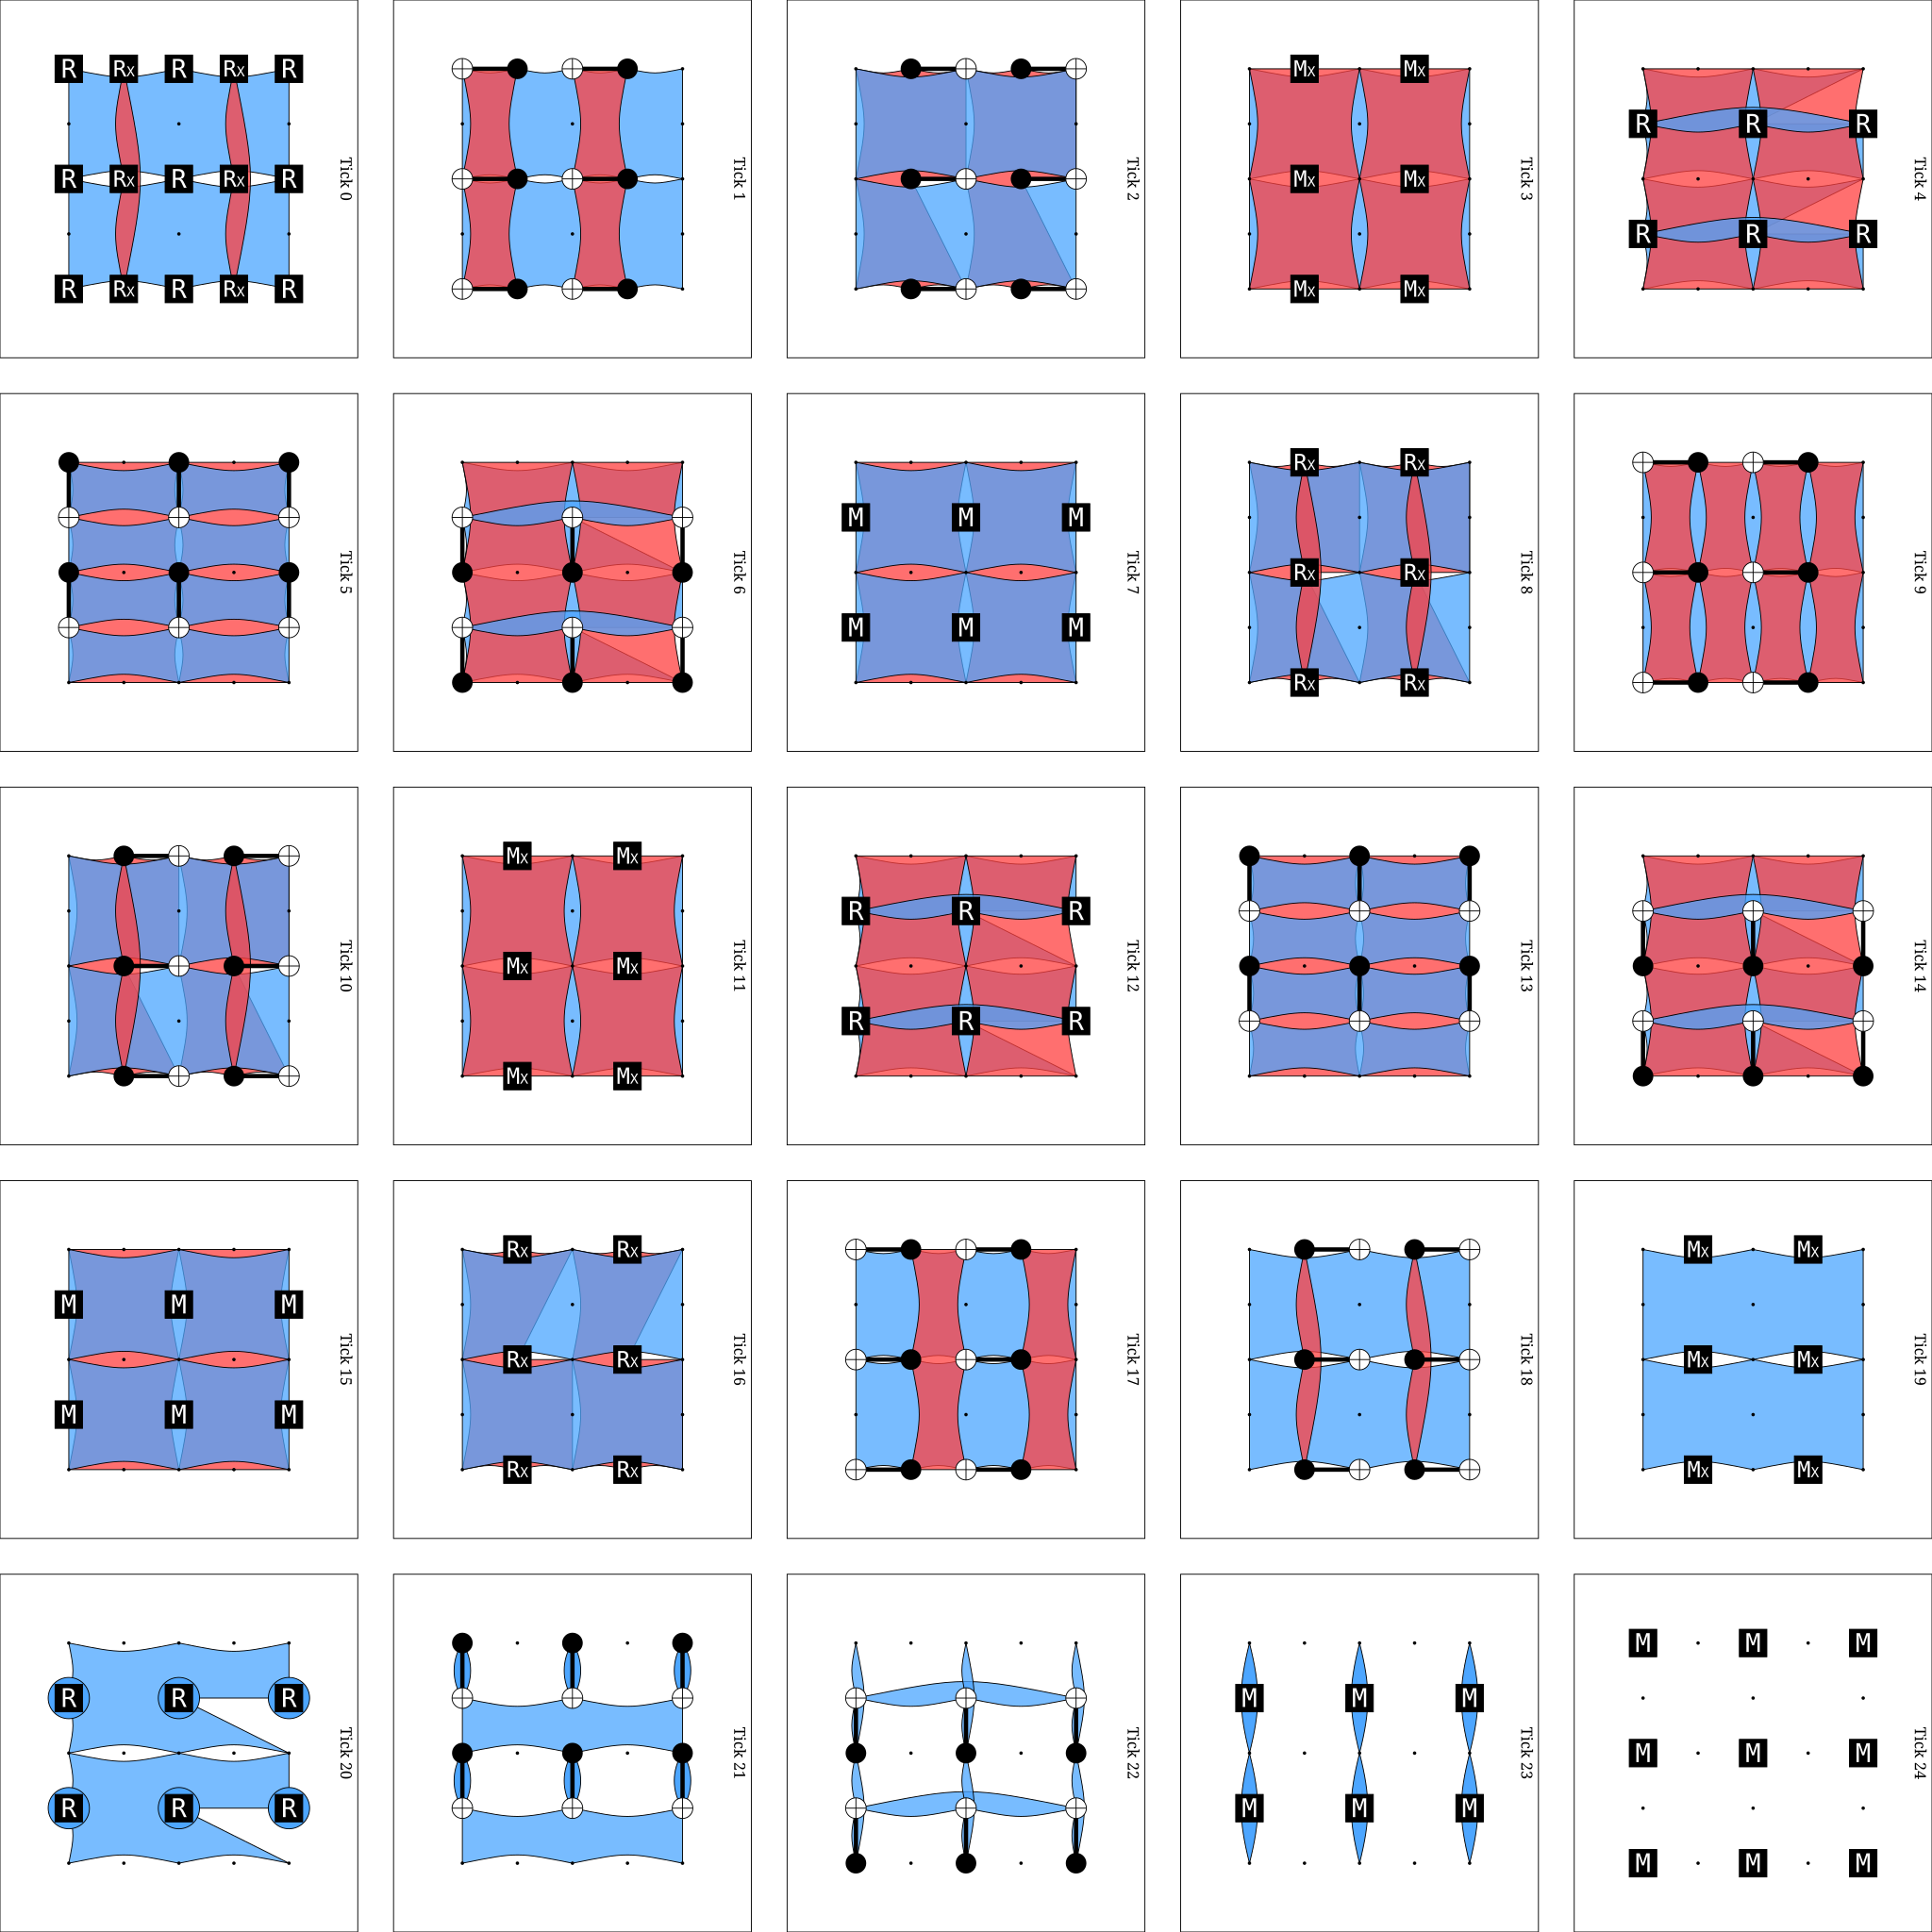

In [4]:
circuit.without_noise().diagram("detslice-with-ops-svg")


## MWPM decoding

Each shot contains d complete XZ rounds. CNOT, reset and measurement noise
use the p above, including final data readout; idle and one-qubit gate noise
are zero. MWPM uses the original same-basis detectors selected from the full
LightStim memory circuit, retaining every physical operation and observable.
This omits the complementary syndrome information.

Error bars show 95% exact binomial intervals for logical failures per complete
memory shot. Finite-distance suppression does not establish a threshold.


d=3: LER=7.080e-04 (708/1,000,000)


d=5: LER=2.010e-04 (201/1,000,000)


d=7: LER=1.020e-04 (102/1,000,000)


d=9: LER=6.300e-05 (63/1,000,000)


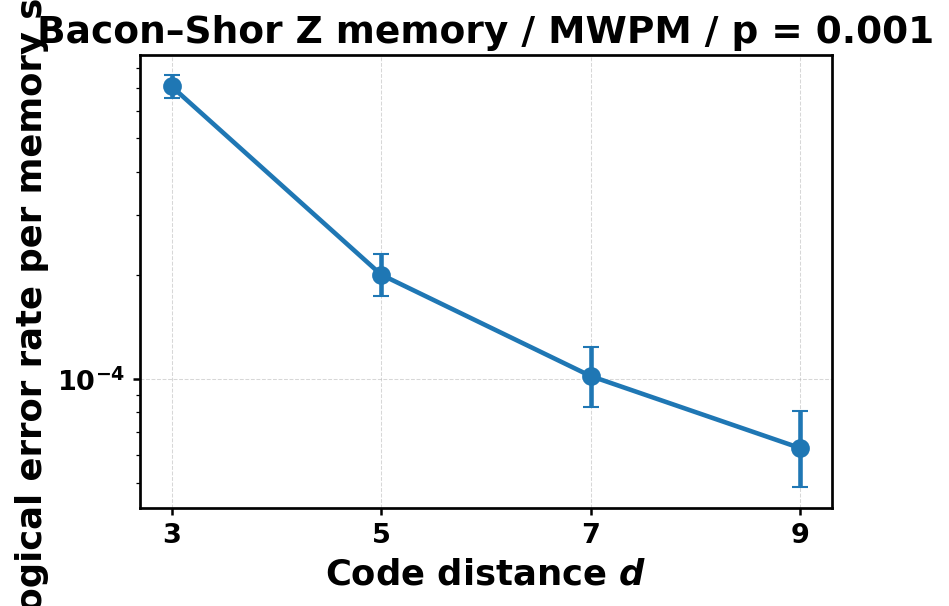

In [5]:
distances = (3, 5, 7, 9)
shots = 1_000_000
pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_shots=shots,
    max_errors=shots + 1,
    batch_size=10_000,
    num_workers=1,
    print_progress=False,
)
logical_error_rates = []
intervals = []

for distance in distances:
    noisy_circuit, *_ = build_circuit(
        "bacon_shor", distance, p,
        basis=basis, rounds=distance, se_circuit="dedicated",
        p_idle=noise_params.p_idle, p_1q=noise_params.p_1q,
        detector_basis=basis,
    )
    stats = pipeline.run(noisy_circuit)
    errors, total = stats.errors, stats.shots
    logical_error_rates.append(stats.logical_error_rate)
    intervals.append((
        beta.ppf(0.025, errors, total - errors + 1) if errors else 0,
        beta.ppf(0.975, errors + 1, total - errors) if errors < total else 1,
    ))
    print(f"d={distance}: LER={stats.logical_error_rate:.3e} ({errors}/{total:,})")

apply_paper_style()
rates = np.array(logical_error_rates)
bounds = np.array(intervals)
fig, ax = plt.subplots(figsize=(5.6, 4.0))
ax.errorbar(distances, rates, yerr=[rates - bounds[:, 0], bounds[:, 1] - rates],
            fmt="o-", capsize=4)
ax.set_yscale("log")
ax.set_xticks(distances)
ax.set_xlabel("Code distance $d$")
ax.set_ylabel("Logical error rate per memory shot")
ax.set_title(f"Bacon–Shor {basis} memory / MWPM / p = {p:g}")
bold_ticks(ax)
fig.tight_layout(pad=0.4)
plt.show()
